<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): stratified
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1752 | Val: 495 | Test: 280


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 4.89e-04 | train loss 0.9749 acc 0.550 | val loss 0.6290 acc 0.762 *


[EfficientNet-B0] Epoch   2/100 | LR: 4.89e-04 | train loss 0.5914 acc 0.729 | val loss 0.6109 acc 0.774 *


[EfficientNet-B0] Epoch   3/100 | LR: 4.89e-04 | train loss 0.5006 acc 0.777 | val loss 0.4815 acc 0.830 *


[EfficientNet-B0] Epoch   4/100 | LR: 4.89e-04 | train loss 0.3998 acc 0.809 | val loss 0.4297 acc 0.834 *


...

[EfficientNet-B0] Epoch  16/100 | LR: 4.89e-07 | train loss 0.2243 acc 0.897 | val loss 0.4245 acc 0.853


[EfficientNet-B0] Epoch  17/100 | LR: 4.89e-07 | train loss 0.2079 acc 0.908 | val loss 0.4001 acc 0.863


[EfficientNet-B0] Epoch  18/100 | LR: 4.89e-07 | train loss 0.2133 acc 0.897 | val loss 0.4149 acc 0.859


[EfficientNet-B0] Epoch  19/100 | LR: 4.89e-07 | train loss 0.2011 acc 0.902 | val loss 0.4093 acc 0.859


[EfficientNet-B0] Epoch  20/100 | LR: 4.89e-08 | train loss 0.2132 acc 0.900 | val loss 0.4039 acc 0.867

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 20.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3956)


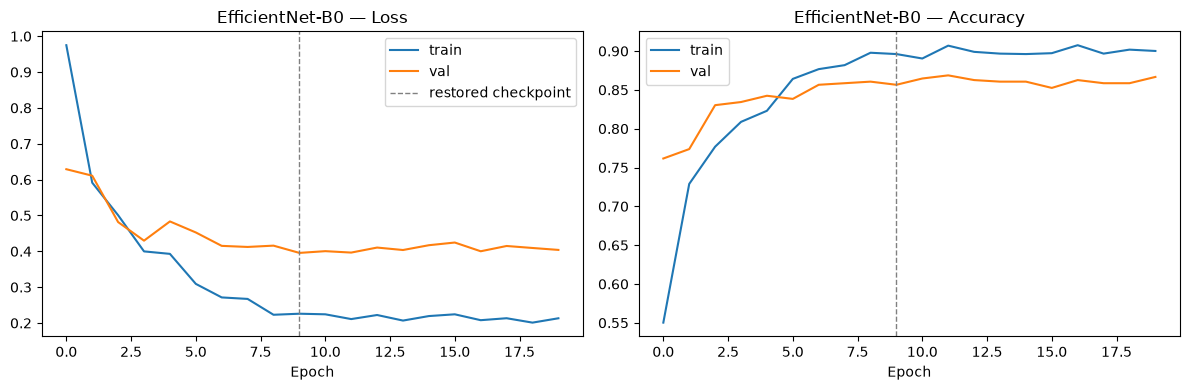

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.864


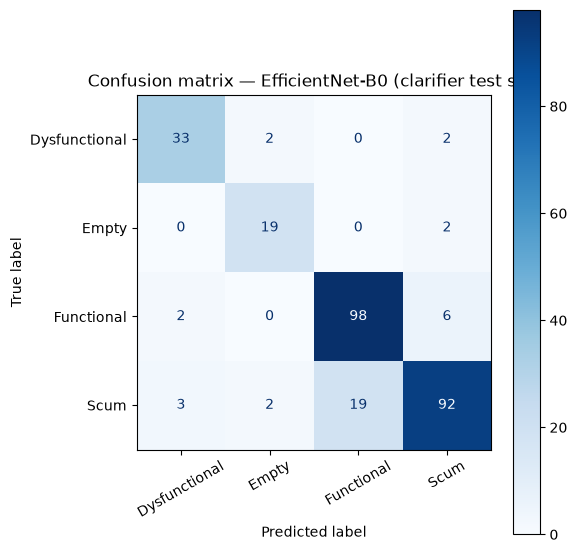

               precision    recall  f1-score   support

Dysfunctional      0.868     0.892     0.880        37
        Empty      0.826     0.905     0.864        21
   Functional      0.838     0.925     0.879       106
         Scum      0.902     0.793     0.844       116

     accuracy                          0.864       280
    macro avg      0.859     0.879     0.867       280
 weighted avg      0.867     0.864     0.863       280



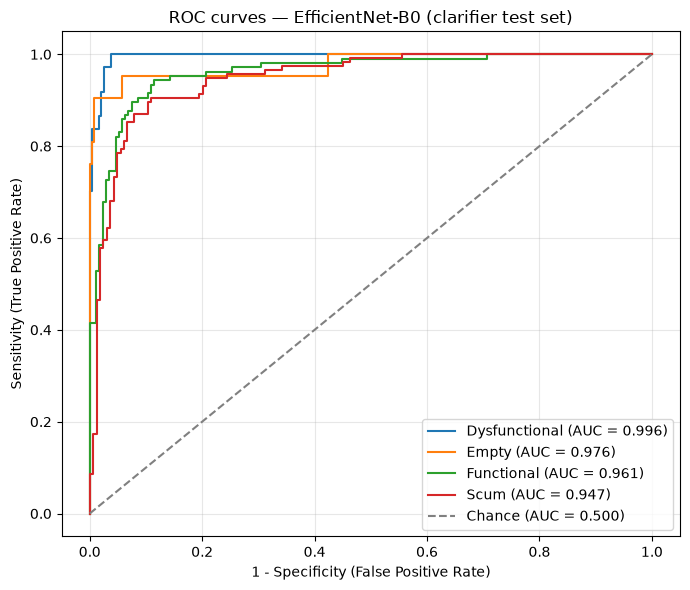

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.996
  Empty          : 0.976
  Functional     : 0.961
  Scum           : 0.947

Mean AUC (over 4/4 classes with test examples): 0.970


(np.float64(0.8642857142857143),
 {'Dysfunctional': 0.9955511066622178,
  'Empty': 0.9760985475271189,
  'Functional': 0.9609086965950987,
  'Scum': 0.9471719932716569})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/clarifier_aug/results_clarifier_efficientnet_b0_stratified.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
